In [2]:
import sys
sys.path.append('../src/')
sys.path.append('../../AIRE/python')
sys.path.append('../')
import os
import copy
from typing import List, Union

import numpy as np
import tensorly as tn
import torch
import math
import matlab.engine
import matplotlib.pyplot as plt
import time
from unpack_ll1 import unpack_ll1
from loewnerize_acts import loewnerize_acts
import ll1_tools
from aire import aire, arnoldi_factors, arnoldi_CNs
from torchvision.datasets import mnist
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Resize, Compose
from models import Lenet5, Lenet300100

In [3]:
# Storage class for hooking into a pytorch model and collecting activation function inputs and outputs
class Storage:
    def __init__(self):
        self.storage = {}
        self.hooks = []

    def __getitem__(self, key: str):
        return self.storage[key]

    def __setitem__(self, key: str, value: torch.Tensor):
        self.storage[key] = value

    def reset(self):
        for key, val in self.storage.items():
            self.storage[key] = []

    def _from_str(self, module, text: str):
        for name in text.split("."):
            module = getattr(module, name)
        return module

    def setup(self, module = None, iter_fn: callable = "named_children", layers: List[Union[torch.nn.Module, str]] = None):
        # either input the iter func or the layers as a list of modules or strings
        def _forward(module, input, output):
            self.storage[module.mod_name].append(output)

        # if you want to see what layers we are iterating over, breakpoint here
        if layers is not None:
            layers = [(layer, self._from_str(module, layer)) if isinstance(layer, str) else layer for layer in layers]
        else:
            iter_fn = getattr(module, iter_fn) if isinstance(iter_fn, str) else iter_fn
            layers = list(iter_fn())

        name_idx = 0
        for mod in layers:
            if isinstance(mod, torch.nn.Module):
                mod_name = f"{mod.__class__.__name__}_{name_idx}"
                name_idx += 1
            else:
                mod_name, mod = mod
            # name = mod_name + '_activation'
            mod.mod_name = mod_name
            self.storage[mod_name] = []
            hook = mod.register_forward_hook(_forward)
            self.hooks.append(hook)

    def __repr__(self):
        return f"Storage: {list(self.storage.keys())}"

    def saveable(self):
        out = {}
        for key, val in self.storage.items():
            if val == []:
                continue

            out[key] = torch.stack(val).cpu().detach().numpy()
        return out


In [4]:
# Load a pre-trained model and evaluate a dataset, collecting activations for anaylsis
device = "cuda"

#********************** LENET300100 **************************
# load MNIST test data
data_dir = f'../data'
test_dataset = mnist.MNIST(
    root=f'{data_dir}',
    train=False,
    transform=ToTensor(),
    download=True
    )
# load model
model = Lenet300100(UseRational=True)
model_path = f'../data/Lenet300100/model/model_state_23.pt'
state_dict = torch.load(model_path, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)

# #********************* LENET5 *****************************
# # load MNIST test data
# data_dir = f'../data'
# test_dataset = mnist.MNIST(
#     root=f'{data_dir}',
#     train=False,
#     transform=Compose([
#         viResize((32,32)),
#         ToTensor()]),
#     download=True
#     )
# # load model
# model = Lenet5(UseRational=True)
# model_path = f'../data/Lenet5/model/model_state_7.pt'
# state_dict = torch.load(model_path, weights_only=True)
# model.load_state_dict(state_dict)
# model.to(device)


batch_size = 256
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=True)
n_classes = 10


# set-up collection
storage = Storage()
storage.setup(model, iter_fn=model.named_modules)

# prepare to evaluate 
model.eval()
correct = 0
seen = 0

# evaluate and collect! 
storage.reset()
for idx, (test_x, test_label) in enumerate(test_loader):
    print(f'Batch: {idx}')
    test_x, test_label = test_x.to(device), test_label.to(device)
    predict_y = model(test_x.float().to(device))
    predict_ys = predict_y.argmax(dim=-1)
    correct += (predict_ys == test_label).sum().item()
    seen += len(test_label)

    # if we want loss too, we'd calculate it here
# Report accuracy
print('Accuracy: {:.4f}'.format(correct / seen))
acts = storage.saveable()

/home/matthewmerris/repos/TensorizedRatNets/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Batch: 0
Batch: 1
Batch: 2
Batch: 3
Batch: 4
Batch: 5
Batch: 6
Batch: 7
Batch: 8
Batch: 9
Batch: 10
Batch: 11
Batch: 12
Batch: 13
Batch: 14
Batch: 15
Batch: 16
Batch: 17
Batch: 18
Batch: 19
Batch: 20
Batch: 21
Batch: 22
Batch: 23
Batch: 24
Batch: 25
Batch: 26
Batch: 27
Batch: 28
Batch: 29
Batch: 30
Batch: 31
Batch: 32
Batch: 33
Batch: 34
Batch: 35
Batch: 36
Batch: 37
Batch: 38
Accuracy: 0.9799


In [5]:
# isolate labels
labels = []
for _, label in test_loader:
    labels.append(label)
labels = np.array(labels).reshape(-1)

print(f'Labels shape: {labels.shape}')

inputs = acts['layers.layer_0.linear']
inputs = inputs.reshape(-1, inputs.shape[-1])
outputs = acts['layers.layer_0.rat']
outputs = outputs.reshape(-1, inputs.shape[-1])
print(inputs.shape)

Labels shape: (9984,)
(9984, 300)


In [6]:
# split inputs and outputs according to label
ins_0 = []
ins_1 = []
ins_2 = []
ins_3 = []
ins_4 = []
ins_5 = []
ins_6 = []
ins_7 = []
ins_8 = []
ins_9 = []
ins = [ins_0, ins_1, ins_2, ins_3, ins_4, ins_5, ins_6, ins_7, ins_8, ins_9]

outs_0 = []
outs_1 = []
outs_2 = []
outs_3 = []
outs_4 = []
outs_5 = []
outs_6 = []
outs_7 = []
outs_8 = []
outs_9 = []
outs = [outs_0, outs_1, outs_2, outs_3, outs_4, outs_5, outs_6, outs_7, outs_8, outs_9]

for idx, lbl in enumerate(labels):
    ins[lbl].append(inputs[idx])
    outs[lbl].append(outputs[idx])

for idx, inpt in enumerate(ins):
    ins[idx] = np.array(inpt)

for idx, output in enumerate(outs):
    outs[idx] = np.array(output)


In [7]:
tensorlab_path = '~/ware/matlab_tools/tensorlab'
# tensorlab_path = '/Users/matthewmerris/tools/matlab_tools/Tensorlab'
eng = matlab.engine.start_matlab()
s = eng.genpath(tensorlab_path)
eng.addpath(s, nargout=0)

# just do it for one targets worth of activations
tmp_ins = ins[0]
tmp_outs = outs[0]
I = math.ceil(tmp_ins.shape[1]/2)
J = tmp_ins.shape[1] - I
loewn_foo = np.empty((I, J, 0))
for i in range(tmp_ins.shape[0]):
    tmp_lwn = eng.loewnerize(tmp_outs[i,:], 'T', tmp_ins[i,:], nargout=1)
    loewn_foo = np.dstack((loewn_foo, tmp_lwn))

In [37]:
subset_sz = 100
subsets = math.floor(loewn_foo.shape[-1]/subset_sz)
thrshld = 1 + 1E-10
CNs = list()
for i in range(2):
    lo = i * subset_sz
    hi = (i + 1) * subset_sz - 1
    tmp_foo = loewn_foo[:,:,lo:hi]
    foo_fctrs = arnoldi_factors(tmp_foo)
    foo_CNs = arnoldi_CNs(foo_fctrs)
    CNs.append(foo_CNs)

2
3


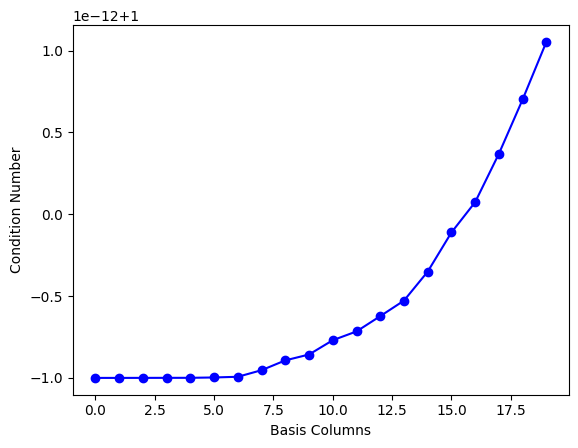

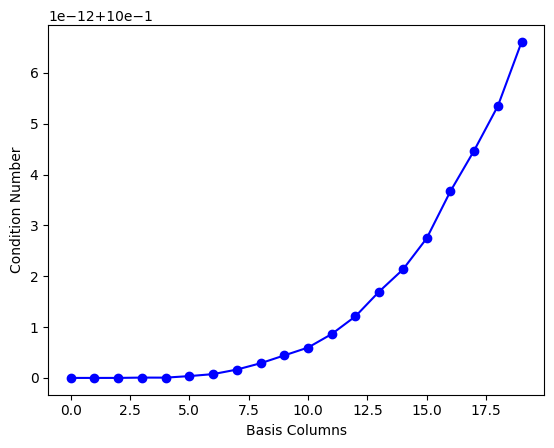

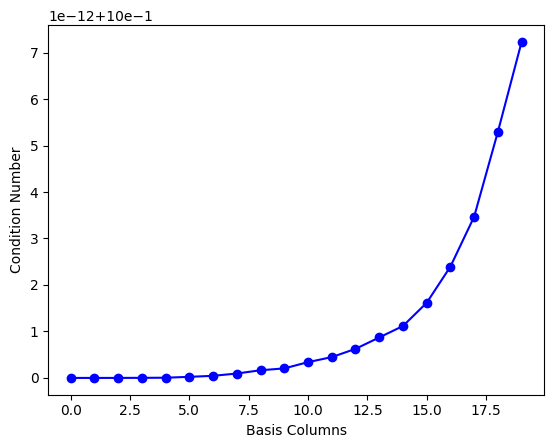

In [68]:
# basic plotting
print(len(CNs))
tmp_CNs = CNs[1]
print(len(tmp_CNs))
upper_lmt = 20
for CN in tmp_CNs:
    plt.plot(CN[:upper_lmt], marker='o', linestyle='-', color='b')
    plt.ylabel('Condition Number')
    plt.xlabel('Basis Columns')
    plt.show()

In [71]:
%%file blokcondia.m
function score = blokcondia(X,U)
% X : tensor (I x J x K) - double or tensorlab tensor
% U : btd tensor - 1 x R cell where U{r} = {Ar, Br, cr, Sr}

% isolate number of terms
R = numel(U);

% isolate multi-linear rank of terms
L = size(U{1}{1}, 2);

% construct global factors
A = [];
B = [];
C = [];

for r = 1:R
    Ar = U{r}{1};
    Br = U{r}{2};
    Cr = U{r}{3};
    Sr = U{r}{4};

    % absorb Sr into Ar
    Ar = Ar * Sr;
    
    % normalize to stabilize pseudoinverse
    scale = sqrt(sum(Ar.^2, 1) + eps);
    Ar = Ar ./ scale;
    Br = Br .* scale;

    % accumulate
    A = [A, Ar];
    B = [B, Br];
    C = [C, Cr];
end

% compute pseudoinverses for computing tucker core
Ap = pinv(A);
Bp = pinv(B);
Cp = pinv(C);

% compute tucker-like core
G = tmprod(X, {Ap, Bp, Cp}, [1 2 3]);
G = double(G);

% construct ideal block core
G_ideal = zeros(size(G));

for r = 1:R
    idx = (r-1)*L+1 : r*L;
    G_ideal(idx, idx, r) = G(idx, idx, r);
end

% compute score
numerator = norm(G(:) - G_ideal(:))^2;
denominator = norm(G(:))^2 + eps;

score = 100 * (1 - numerator / denominator);

end

Overwriting blokcondia.m


In [80]:
%%file blokcondia_invariant.m
function [score, diagnostics] = blokcondia_invariant(X,U)
% X : tensor (I x J x K) - double or tensorlab tensor
% U : btd tensor - 1 x R cell where U{r} = {Ar, Br, cr, Sr}

% isolate number of terms
R = numel(U);

% isolate multi-linear rank of terms
L = size(U{1}{1}, 2);

% construct global factors
A = [];
B = [];
C = [];

block_CNs = zeros(R,1);

for r = 1:R
    Ar = U{r}{1};
    Br = U{r}{2};
    Cr = U{r}{3};
    Sr = U{r}{4};

    % absorb block core
    Mr = Ar * Sr * Br';

    % SVD canonicalization to remove projective ambiguity
    [Ur, Sr_svd, Vr] = svd(Mr, 'econ');
    Ar_canon = Ur(:,1:L);
    Br_canon = Vr(:,1:L) * Sr_svd(1:L,1:L);
    
    % normalize to stabilize pseudoinverse
    scale = sqrt(sum(Ar.^2, 1) + eps);
    Ar_canon = Ar_canon ./ scale;
    Br_canon = Br_canon .* scale;

    % accumulate
    A = [A, Ar_canon];
    B = [B, Br_canon];
    C = [C, Cr];

    block_CNs(r) = cond(Sr_svd(1:L,1:L));
end

% compute pseudoinverses for computing tucker core
Ap = pinv(A);
Bp = pinv(B);
Cp = pinv(C);

% compute tucker-like core
G = tmprod(X, {Ap, Bp, Cp}, [1 2 3]);
G = double(G);

% construct ideal block core
G_ideal = zeros(size(G));

for r = 1:R
    idx = (r-1)*L+1 : r*L;
    G_ideal(idx, idx, r) = G(idx, idx, r);
end

% compute score
off_block_energy = norm(G(:) - G_ideal(:))^2;
total_energy = norm(G(:))^2 + eps;

score = 100 * (1 - off_block_energy / total_energy);

% collect diagnostics
diagnostics = struct();

diagnostics.total_core_energy = total_energy;
diagnostics.off_block_energy = off_block_energy;
diagnostics.block_core_energy = norm(G_ideal(:))^2;
diagnostics.relative_offblock_energy = off_block_energy / total_energy;
diagnostics.block_condition_numbers = block_CNs;
diagnostics.mean_condition_number = mean(block_CNs);

% compute subspace overlap diagnostics
overlap_A = zeros(R);
overlap_B = zeros(R);

for i = 1:R
    idx_i = (i-1)*L +1 : i*L;
    Ai = A(:,idx_i);
    Bi = B(:,idx_i);

    for j = i+1:R
        idx_j = (j-1)*L + 1 : j*L;
        Aj = A(:, idx_j);
        Bj = B(:, idx_j);

        overlap_A(i,j) = norm(Ai' * Aj, 'fro')^2;
        overlap_B(i,j) = norm(Bi' * Bj, 'fro')^2;
    end
end
diagnostics.subspace_overlap_A = overlap_A;
diagnostics.subspace_overlap_B = overlap_B;

end

Overwriting blokcondia_invariant.m


In [103]:
%%file test_blokcondia.m
function [U,X] = test_blokcondia(test)
% test - boolean, if 1 produces exact random orthogonal LL1 tensor, if 0 produces minimal exact LL1 tensor

if test
    % test case parameters
    I = 20;
    J = 20;
    K = 10;
    R = 5;
    L = 2;
    % exact random orthogonal LL1 model
    U = cell(1,R);
    for r = 1:R
        % random orthonormal factors
        [Qa,~] = qr(randn(I,L),0);
        [Qb,~] = qr(randn(J,L),0);
        % random core
        Sr = randn(L,L);
        % component vector
        cr = zeros(K,1);
        cr(r) = 1;

        U{r} = {Qa, Qb, cr, Sr};
    end
    % build exact tensor
    X = zeros(I,J,K);
    for r = 1:R
        Ar = U{r}{1};
        Br = U{r}{2};
        cr = U{r}{3};
        Sr = U{r}{4};

        Mr = Ar * Sr * Br';
        for k = 1:K
            X(:,:,k) = X(:,:,k) + Mr * cr(k);
        end
    end
else
    % test case parameters
    I = 4;
    J = 4;
    K = 2;
    R = 2;
    L = 2;

    % build exact LL1 model
    U = cell(1,R);

    % Block 1
    A1 = [1 0;
          0 1;
          0 0;
          0 0];
    B1 = [1 0;
          0 1;
          0 0;
          0 0];
    c1 = [1;
          0];
    S1 = eye(L);
    U{1} = {A1, B1, c1, S1};

    % Block 2 
    A2 = [0 0;
          0 0;
          1 0;
          0 1];
    B2 = [0 0;
          0 0;
          1 0;
          0 1];
    c2 = [0;
          1];
    S2 = eye(L);
    U{2} = {A2, B2, c2, S2};

    % build exact tensor
    X = zeros(I,J,K);

    for r = 1:R
        Ar = U{r}{1};
        Br = U{r}{2};
        cr = U{r}{3};
        Sr = U{r}{4};

        Mr = Ar * Sr * Br';
        for k = 1:K
            X(:,:,k) = X(:,:,k) + Mr * cr(k);
        end
    end
end
    

Overwriting test_blokcondia.m


In [115]:
# testing blokcondia
print('Minimal Exact Test')
foo_U, foo_X = eng.test_blokcondia(0, nargout=2)
score = eng.blokcondia(foo_X, foo_U, nargout=1)
print(f'Score: {score}')
score_inv,_ = eng.blokcondia_invariant(foo_X, foo_U, nargout=2)
print(f'Score_inv: {score_inv}')
print('Random Orthogonal Exact Test')
foo_U, foo_X = eng.test_blokcondia(1, nargout=2)
score = eng.blokcondia(foo_X, foo_U, nargout=1)
print(f'Score: {score}')
score_inv,_ = eng.blokcondia_invariant(foo_X, foo_U, nargout=2)
print(f'Score_inv: {score_inv}')

print()
print('Overfactoring Test')
rank = 5
L = 2
L1 = L * np.ones(rank)
foo_U1,_ = eng.ll1(foo_X, L1, nargout=2)
fit_1 = 1 - eng.frobll1res(foo_X, foo_U1, nargout=1) / eng.frob(foo_X, nargout=1)
sc1 = eng.blokcondia(foo_X, foo_U1, nargout=1)
sc1_inv,_ = eng.blokcondia_invariant(foo_X, foo_U1, nargout=2)
print(f'Rank: {rank} \t Fit: {fit_1} \t Score: {sc1} \t Score_inv: {sc1_inv}')
rank = 8
L2 = L * np.ones(rank)
foo_U2,_ = eng.ll1(foo_X, L2, nargout=2)
fit_2 = 1 - eng.frobll1res(foo_X, foo_U2, nargout=1) / eng.frob(foo_X, nargout=1)
sc2 = eng.blokcondia(foo_X, foo_U2, nargout=1)
sc2_inv,_ = eng.blokcondia_invariant(foo_X, foo_U2, nargout=2)
print(f'Rank: {rank} \t Fit: {fit_2} \t Score: {sc2} \t Score_inv: {sc2_inv}')

Minimal Exact Test
Score: 100.0
Score_inv: 100.0
Random Orthogonal Exact Test
Score: 100.0
Score_inv: 100.0

Overfactoring Test
Rank: 5 	 Fit: 0.9999999999999999 	 Score: 100.0 	 Score_inv: 100.0
Rank: 8 	 Fit: 0.9999956302284204 	 Score: 3.2833950279728352 	 Score_inv: 1.1687289738146145


In [53]:
rank = 10
rat_deg = 3
L = rat_deg * np.ones(rank)
foo_U, tmp_out = eng.ll1(tmp_foo, L, nargout=2)

In [62]:
print(len(foo_U))
print(len(foo_U[0]))
print(foo_U[0][3])
print(np.array(foo_U[0][3]).shape)

10
4
[[1.0,0.0,0.0],[0.0,1.0,0.0],[0.0,0.0,1.0]]
(3, 3)


In [82]:
# ranks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] #, 30, 35, 40, 45] #, 50, 55, 60, 65, 70, 75, 80, 85, 90, 99]
# ranks = [99, 100, 101, 102]
ranks = [60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
rat_deg = 3
tmp_foo = np.copy(loewn_foo[:,:,:subset_sz])
for rank in ranks:
    print(f'Rank: {rank}')
    L = rat_deg * np.ones(rank)
    tmp_U, tmp_out = eng.ll1(tmp_foo, L, nargout=2)
    fit = 1 - eng.frobll1res(tmp_foo, tmp_U, nargout=1) / eng.frob(tmp_foo, nargout=1)
    print(f'Fit: {fit}')
    score = eng.blokcondia(tmp_foo, tmp_U, nargout=1)
    print(f'BLOKCONDIA: {score}')
    score_inv,_ = eng.blokcondia_invariant(tmp_foo, tmp_U, nargout=2)
    print(f'BLOKCONDIA_INV: {score_inv}')
    


Rank: 60
Fit: 0.8150810925126926
BLOKCONDIA: 0.030666330969975064
BLOKCONDIA_INV: 0.027762130368202964
Rank: 61
Fit: 0.8163191871621889
BLOKCONDIA: 0.026320512738298163
BLOKCONDIA_INV: 0.015819183439391704
Rank: 62
Fit: 0.8199857802183776
BLOKCONDIA: 0.02763468144254544
BLOKCONDIA_INV: 0.03475731878200827
Rank: 63
Fit: 0.8252568437360532
BLOKCONDIA: 0.034365983915718434
BLOKCONDIA_INV: 0.012887682731699268
Rank: 64
Fit: 0.827606517915792
BLOKCONDIA: 0.028937665263761847
BLOKCONDIA_INV: 0.011993857525305351
Rank: 65
Fit: 0.8289133138851452
BLOKCONDIA: 0.021191316557700457
BLOKCONDIA_INV: 0.02100913482980804
Rank: 66
Fit: 0.8368271135886244
BLOKCONDIA: 0.043557619123879565
BLOKCONDIA_INV: 0.024159074890583998
Rank: 67
Fit: 0.8334475353546202
BLOKCONDIA: 0.01926249578863004
BLOKCONDIA_INV: 0.025675947516257125
Rank: 68
Fit: 0.8422093798483914
BLOKCONDIA: 0.02116250017081267
BLOKCONDIA_INV: 0.0135759301790217
Rank: 69
Fit: 0.8449448668452797
BLOKCONDIA: 0.035986859875791755
BLOKCONDIA_INV: